# Phase 2 : Prétraitement, Augmentation & DataLoaders

**Objectif :** Ce notebook prépare les données pour l'entraînement. Il couvre la séparation sécurisée du dataset (anti-fuite), l'imputation des valeurs manquantes, l'encodage tabulaire et la configuration des flux de données (DataLoaders) pour PyTorch.

## 1. Séparation Sécurisée des Données (Le Split anti-fuite)


Comme découvert lors de la Phase 1, le dataset HAM10000 contient de multiples images pour une même lésion (`lesion_id`). Pour éviter que notre modèle ne triche en mémorisant des images similaires dans le Train et le Test (Data Leakage), nous abandonnons le `train_test_split` classique au profit d'un `GroupShuffleSplit`.

Puisque nous voulons une répartition **80% (Train) / 10% (Validation) / 10% (Test)**, nous allons procéder en deux étapes :
1. Séparer 80% pour le Train et 20% pour un ensemble Temporaire.
2. Couper cet ensemble Temporaire en deux (50/50) pour obtenir la Validation et le Test.

**L’idée est simple :** toutes les images du même groupe vont soit dans train, soit dans test, mais jamais dans les deux.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
import os

# 1. Chargement des données brutes
csv_path = '../data/raw/HAM10000_metadata.csv'
df = pd.read_csv(csv_path)

print(f"Taille initiale du dataset : {len(df)} images\n")

# ==========================================
# ÉTAPE 1 : Split Train (80%) / Temp (20%)
# ==========================================
gss1 = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
# La fonction next() permet de récupérer les index générés par le split
train_idx, temp_idx = next(gss1.split(df, groups=df['lesion_id']))

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

# ==========================================
# ÉTAPE 2 : Split Temp en Val (50%) / Test (50%)
# ==========================================
gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['lesion_id']))

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

# Affichage des résultats
print("--- Répartition des ensembles ---")
print(f"Images Train : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Images Val   : {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Images Test  : {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

Taille initiale du dataset : 10015 images

--- Répartition des ensembles ---
Images Train : 7991 (79.8%)
Images Val   : 1025 (10.2%)
Images Test  : 999 (10.0%)


### 1.1 Le "Sanity Check" Absolu
En ingénierie des données, il ne faut jamais faire confiance aveuglément à une fonction. Nous allons vérifier mathématiquement qu'aucun identifiant de lésion (`lesion_id`) présent dans le set d'entraînement ne s'est glissé dans les sets de validation ou de test. C'est la garantie de notre rigueur scientifique.

In [2]:
# Extraction des identifiants uniques (sous forme de Set mathématique pour faire des intersections)
train_lesions = set(train_df['lesion_id'])
val_lesions = set(val_df['lesion_id'])
test_lesions = set(test_df['lesion_id'])

# Vérification des intersections (ce qui existe à la fois dans A et dans B)
leak_train_val = train_lesions.intersection(val_lesions)
leak_train_test = train_lesions.intersection(test_lesions)
leak_val_test = val_lesions.intersection(test_lesions)

print("--- Audit de Sécurité (Data Leakage) ---")

if len(leak_train_val) == 0 and len(leak_train_test) == 0 and len(leak_val_test) == 0:
    print("✅ SUCCÈS TOTAL : Aucune fuite de données détectée. Les ensembles sont parfaitement hermétiques.")
    print(f"Nombre de lésions uniques dans Train : {len(train_lesions)}")
    print(f"Nombre de lésions uniques dans Val   : {len(val_lesions)}")
    print(f"Nombre de lésions uniques dans Test  : {len(test_lesions)}")
else:
    print("❌ ALERTE FATALE : Fuite de données détectée !")
    print(f"Doublons Train/Val : {len(leak_train_val)}")
    print(f"Doublons Train/Test : {len(leak_train_test)}")

--- Audit de Sécurité (Data Leakage) ---
✅ SUCCÈS TOTAL : Aucune fuite de données détectée. Les ensembles sont parfaitement hermétiques.
Nombre de lésions uniques dans Train : 5976
Nombre de lésions uniques dans Val   : 747
Nombre de lésions uniques dans Test  : 747


## 2. Prétraitement Tabulaire et Sauvegarde des Artefacts

Pour alimenter notre futur modèle Random Forest et notre API de production, nous devons transformer nos données cliniques brutes en un format mathématiquement exploitable :
1. **Imputation :** Remplacement des valeurs manquantes de l'âge. (Calcul basé *uniquement* sur le set d'entraînement).
2. **Encodage One-Hot :** Transformation des variables textuelles (Sexe, Localisation) en colonnes binaires (0 ou 1).
3. **Normalisation :** Mise à l'échelle de l'âge avec `StandardScaler` pour ramener les valeurs autour de 0.
4. **Sauvegarde :** Exportation des modèles de transformation (`.pkl`) pour garantir la reproductibilité en production.

In [3]:
# 1. Imputation de l'âge
# Calcul de la médiane STRICTEMENT sur le dataset d'entraînement
median_age = train_df['age'].median()

# Application de cette médiane sur les 3 ensembles
train_df.loc[:, 'age'] = train_df['age'].fillna(median_age)
val_df.loc[:, 'age'] = val_df['age'].fillna(median_age)
test_df.loc[:, 'age'] = test_df['age'].fillna(median_age)

print(f"Âge médian calculé sur le Train et utilisé pour l'imputation : {median_age} ans")
print(f"Vérification des NaN restants dans l'âge (Train) : {train_df['age'].isnull().sum()}")

Âge médian calculé sur le Train et utilisé pour l'imputation : 50.0 ans
Vérification des NaN restants dans l'âge (Train) : 0


### Encodage, Normalisation et Création des DataFrames finaux

Nous utilisons `Scikit-Learn` pour créer des objets de transformation (`OneHotEncoder`, `StandardScaler`). Le fait de les "fitter" (entraîner) uniquement sur `train_df` nous assure de ne pas créer de fuite de données.

In [7]:
from glob import glob
import os

print("Recréation des colonnes 'path' et 'dx_name'...")

# 1. Mapping des chemins d'images (vital pour le CNN plus tard)
image_paths = {os.path.splitext(os.path.basename(x))[0]: x 
               for x in glob(os.path.join('../data/raw', '*', '*.jpg'))}

# 2. Mapping des noms complets
lesion_names = {
    'nv': 'Nævus mélanocytaire (Bénin)',
    'mel': 'Mélanome (Malin)',
    'bkl': 'Kératose séborrhéique (Bénin)',
    'bcc': 'Carcinome basocellulaire (Malin)',
    'akiec': 'Kératose actinique (Précancéreux)',
    'vasc': 'Lésion vasculaire (Bénin)',
    'df': 'Dermatofibrome (Bénin)'
}

# 3. Application sur nos 3 ensembles (Train, Val, Test)
for dataframe in [train_df, val_df, test_df]:
    dataframe['path'] = dataframe['image_id'].map(image_paths)
    dataframe['dx_name'] = dataframe['dx'].map(lesion_names)

print("✅ Colonnes recréées avec succès ! Vous pouvez relancer la cellule 8.")

Recréation des colonnes 'path' et 'dx_name'...
✅ Colonnes recréées avec succès ! Vous pouvez relancer la cellule 8.


In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

# Définition de nos colonnes
cat_cols = ['sex', 'localization']
num_cols = ['age']

# --- A. Encodage One-Hot (Sexe & Localisation) ---
# sparse_output=False (ou sparse=False selon la version de sklearn) pour obtenir un tableau numpy standard
# handle_unknown='ignore' : vital pour la production si l'API reçoit une nouvelle localisation inconnue
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_df[cat_cols]) # FIT SUR LE TRAIN UNIQUEMENT
encoded_cols = encoder.get_feature_names_out(cat_cols)

# --- B. Normalisation (Âge) ---
scaler = StandardScaler()
scaler.fit(train_df[num_cols]) # FIT SUR LE TRAIN UNIQUEMENT

# --- C. Fonction pour appliquer les transformations ---
def process_tabular_data(df):
    # Transformation des catégories
    encoded_data = encoder.transform(df[cat_cols])
    encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols, index=df.index)
    
    # Transformation de l'âge
    scaled_age = scaler.transform(df[num_cols])
    age_df = pd.DataFrame(scaled_age, columns=['age_scaled'], index=df.index)
    
    # Assemblage : On garde les métadonnées utiles (image_id, path, dx) et on y colle nos nouvelles features
    meta_cols = ['image_id', 'dx', 'dx_name', 'path', 'lesion_id']
    final_df = pd.concat([df[meta_cols], age_df, encoded_df], axis=1)
    
    return final_df

# Application de la fonction
train_tab = process_tabular_data(train_df)
val_tab = process_tabular_data(val_df)
test_tab = process_tabular_data(test_df)

print(f"Nouvelles dimensions tabulaires (Train) : {train_tab.shape}")
display(train_tab.head(3))

Nouvelles dimensions tabulaires (Train) : (7991, 24)


,image_id,dx,dx_name,path,lesion_id,age_scaled,sex_female,sex_male,sex_unknown,localization_abdomen,...,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity
0,ISIC_0027419,bkl,Kératose séborrhéique (Bénin),../data/raw\HAM10000_images_part1\ISIC_0027419...,HAM_0000118,1.683974,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,ISIC_0025030,bkl,Kératose séborrhéique (Bénin),../data/raw\HAM10000_images_part1\ISIC_0025030...,HAM_0000118,1.683974,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,ISIC_0026769,bkl,Kératose séborrhéique (Bénin),../data/raw\HAM10000_images_part1\ISIC_0026769...,HAM_0002730,1.683974,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Sauvegarde pour la Production (MLOps)

Nos données tabulaires sont prêtes. Nous sauvegardons les DataFrames nettoyés en `.csv` pour l'entraînement du Random Forest (Notebook 04), et nous sauvegardons nos objets `encoder` et `scaler` en `.pkl` pour le backend FastAPI.

In [9]:
# Création des dossiers cibles s'ils n'existent pas
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Sauvegarde des artefacts (pour l'API)
joblib.dump(encoder, '../models/encoder.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

# Sauvegarde des CSV propres (pour le Random Forest)
train_tab.to_csv('../data/processed/tabular_train.csv', index=False)
val_tab.to_csv('../data/processed/tabular_val.csv', index=False)
test_tab.to_csv('../data/processed/tabular_test.csv', index=False)

print("✅ SUCCÈS : Artefacts (.pkl) et données tabulaires (.csv) sauvegardés !")

✅ SUCCÈS : Artefacts (.pkl) et données tabulaires (.csv) sauvegardés !


## 3. Définition des Pipelines de Transformation d'Images (CNN)

Pour alimenter notre modèle de vision par ordinateur (EfficientNetB0), les images doivent subir une série de transformations géométriques et colorimétriques (Data Augmentation) lors de l'entraînement. Cela permet de combattre le surapprentissage (overfitting) et de compenser en partie le déséquilibre des classes. 

**Stratégie adoptée :**
* **Train :** Application de recadrages aléatoires, retournements (flips), rotations et variations de couleurs (pour simuler différents éclairages de microscopes).
* **Validation / Test :** Application stricte d'un recadrage central. Aucune augmentation n'est appliquée ici, car nous voulons évaluer le modèle sur des données non altérées.
* **Standardisation :** Toutes les images sont normalisées avec les valeurs `Mean` et `Std` officielles du dataset ImageNet.

In [12]:
import torchvision.transforms as transforms

print("Configuration des pipelines de transformation PyTorch...")

# Constantes de normalisation officielles d'ImageNet (Obligatoire pour le Transfer Learning)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ==========================================
# 1. Pipeline d'Entraînement (Data Augmentation)
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize(232), # Redimensionnement initial légèrement plus grand
    transforms.RandomCrop(224), # Découpage aléatoire au format final
    transforms.RandomHorizontalFlip(p=0.5), # Miroir horizontal (1 chance sur 2)
    transforms.RandomVerticalFlip(p=0.5),   # Miroir vertical (1 chance sur 2)
    transforms.RandomRotation(degrees=20),  # Rotation aléatoire jusqu'à 20 degrés
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05), # Variation d'éclairage
    transforms.ToTensor(), # Conversion de l'image (Pixel 0-255) en Tenseur mathématique (0.0 - 1.0)
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD) # Normalisation statistique
])

# ==========================================
# 2. Pipeline de Validation et Test (Strict)
# ==========================================
val_transforms = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224), # Découpage parfait au centre
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("✅ Pipelines 'train_transforms' et 'val_transforms' créés avec succès !")

Configuration des pipelines de transformation PyTorch...
✅ Pipelines 'train_transforms' et 'val_transforms' créés avec succès !


## 4. Stratégie de Déséquilibre et Création du Dataset PyTorch

### 4.1 Encodage des Labels et WeightedRandomSampler (Pour le CNN)
Les réseaux de neurones (PyTorch) n'acceptent pas des chaînes de caractères comme `mel` ou `nv` pour la classification, ils ont besoin d'entiers (0, 1, 2... 6). Nous allons créer un dictionnaire de mapping.
Ensuite, nous calculons le poids de chaque image dans le set d'entraînement pour forcer PyTorch à sur-échantillonner les classes minoritaires (Oversampling dynamique).

In [13]:
import torch
from torch.utils.data import WeightedRandomSampler

print("Calcul des poids d'échantillonnage pour le CNN...")

# 1. Création du dictionnaire de mapping des labels (String -> Int)
# On s'assure d'avoir un ordre fixe, par exemple par ordre alphabétique des classes
classes = sorted(train_df['dx'].unique())
label_map = {class_name: idx for idx, class_name in enumerate(classes)}

print(f"Mapping des classes : {label_map}\n")

# 2. Calcul du nombre d'images par classe dans le Train
class_counts = train_df['dx'].value_counts().to_dict()

# 3. Calcul du poids de chaque classe (Formule : 1.0 / nombre_occurrences)
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}

# 4. Attribution du poids correspondant à CHAQUE image du set d'entraînement
sample_weights = [class_weights[label] for label in train_df['dx']]

# 5. Conversion en Tenseur PyTorch et instanciation du Sampler
sample_weights_tensor = torch.DoubleTensor(sample_weights)

# Le Sampler PyTorch : Il va piocher 'len(train_df)' images, mais en utilisant nos probabilités truquées
sampler = WeightedRandomSampler(
    weights=sample_weights_tensor, 
    num_samples=len(sample_weights_tensor), 
    replacement=True # VITAL : Autorise à piocher plusieurs fois la même image minoritaire (oversampling)
)

print("✅ WeightedRandomSampler configuré avec succès ! (Rappel : Ne pas utiliser class_weight dans la Loss du CNN)")

Calcul des poids d'échantillonnage pour le CNN...
Mapping des classes : {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

✅ WeightedRandomSampler configuré avec succès ! (Rappel : Ne pas utiliser class_weight dans la Loss du CNN)


### 4.2 La classe personnalisée `HAM10000Dataset`
Pour que PyTorch puisse lire nos images sur le disque dur au fur et à mesure (pour ne pas saturer la RAM), nous devons créer une classe qui hérite de `torch.utils.data.Dataset`. Elle devra charger l'image, lui appliquer le pipeline de transformation (défini à l'étape 3), et renvoyer l'image et son label.

In [14]:
from torch.utils.data import Dataset
from PIL import Image

class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None, label_map=None):
        """
        Args:
            dataframe (Pandas DataFrame): Le dataframe contenant 'path' et 'dx'
            transform (callable, optional): Pipeline de transformation PyTorch
            label_map (dict): Dictionnaire pour convertir 'dx' en entier
        """
        # On réinitialise l'index pour s'assurer que .loc[idx] fonctionne de 0 à len(df)-1
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = label_map
        
    def __len__(self):
        # Indique à PyTorch la taille du dataset
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        # 1. Récupération du chemin de l'image
        img_path = self.dataframe.loc[idx, 'path']
        
        # 2. Chargement de l'image (convert('RGB') sécurise le format)
        image = Image.open(img_path).convert('RGB')
        
        # 3. Récupération et conversion du label
        label_str = self.dataframe.loc[idx, 'dx']
        label_idx = self.label_map[label_str]
        
        # 4. Application des transformations (Data Augmentation ou normalisation)
        if self.transform:
            image = self.transform(image)
            
        # On renvoie le Tenseur Image et le Tenseur Label
        return image, torch.tensor(label_idx, dtype=torch.long)

print("✅ Classe Dataset définie avec succès !")

✅ Classe Dataset définie avec succès !


## 5. Construction et Vérification des DataLoaders

Nous instancions maintenant nos Datasets et DataLoaders.
**Règles de configuration :**
* `train_loader` : Utilise le `WeightedRandomSampler`. (Attention : lorsqu'un sampler personnalisé est utilisé, le paramètre `shuffle` doit être désactivé ou ignoré, car le sampler s'occupe déjà de mélanger les données intelligemment).
* `val_loader` et `test_loader` : Aucun sampler, `shuffle=False`. On veut juste lire les données dans l'ordre pour les évaluer.

In [15]:
from torch.utils.data import DataLoader

print("Création des Datasets et DataLoaders...")

# Définition de la taille du batch (32 est standard pour EfficientNetB0 sur une carte graphique classique)
BATCH_SIZE = 32

# 1. Instanciation des Datasets (On relie les DataFrames, les Transforms et le Label Map)
train_dataset = HAM10000Dataset(train_df, transform=train_transforms, label_map=label_map)
val_dataset = HAM10000Dataset(val_df, transform=val_transforms, label_map=label_map)
test_dataset = HAM10000Dataset(test_df, transform=val_transforms, label_map=label_map)

# 2. Instanciation des DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=sampler, # Notre système de poids anti-déséquilibre
    # num_workers=2  # À décommenter plus tard si vous êtes sur Linux/Colab pour accélérer le chargement
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders prêts !")
print(f"Nombre de batches par époque (Train) : {len(train_loader)}")

Création des Datasets et DataLoaders...
✅ DataLoaders prêts !
Nombre de batches par époque (Train) : 250


### 5.1 Sanity Check Visuel (Le Test Ultime)

Affichons un batch généré par notre `train_loader`.
Puisque nos images ont été normalisées pour ImageNet (valeurs mathématiques souvent négatives), nous devons les "dénormaliser" manuellement pour que Matplotlib puisse les afficher avec leurs vraies couleurs. Nous vérifierons également si le Sampler a bien forcé l'apparition des classes minoritaires (comme le mélanome).

Format du Tenseur Image : torch.Size([32, 3, 224, 224]) -> [Batch, Canaux (RGB), Hauteur, Largeur]
Format du Tenseur Label : torch.Size([32])

--- Visualisation d'un Batch d'Entraînement ---


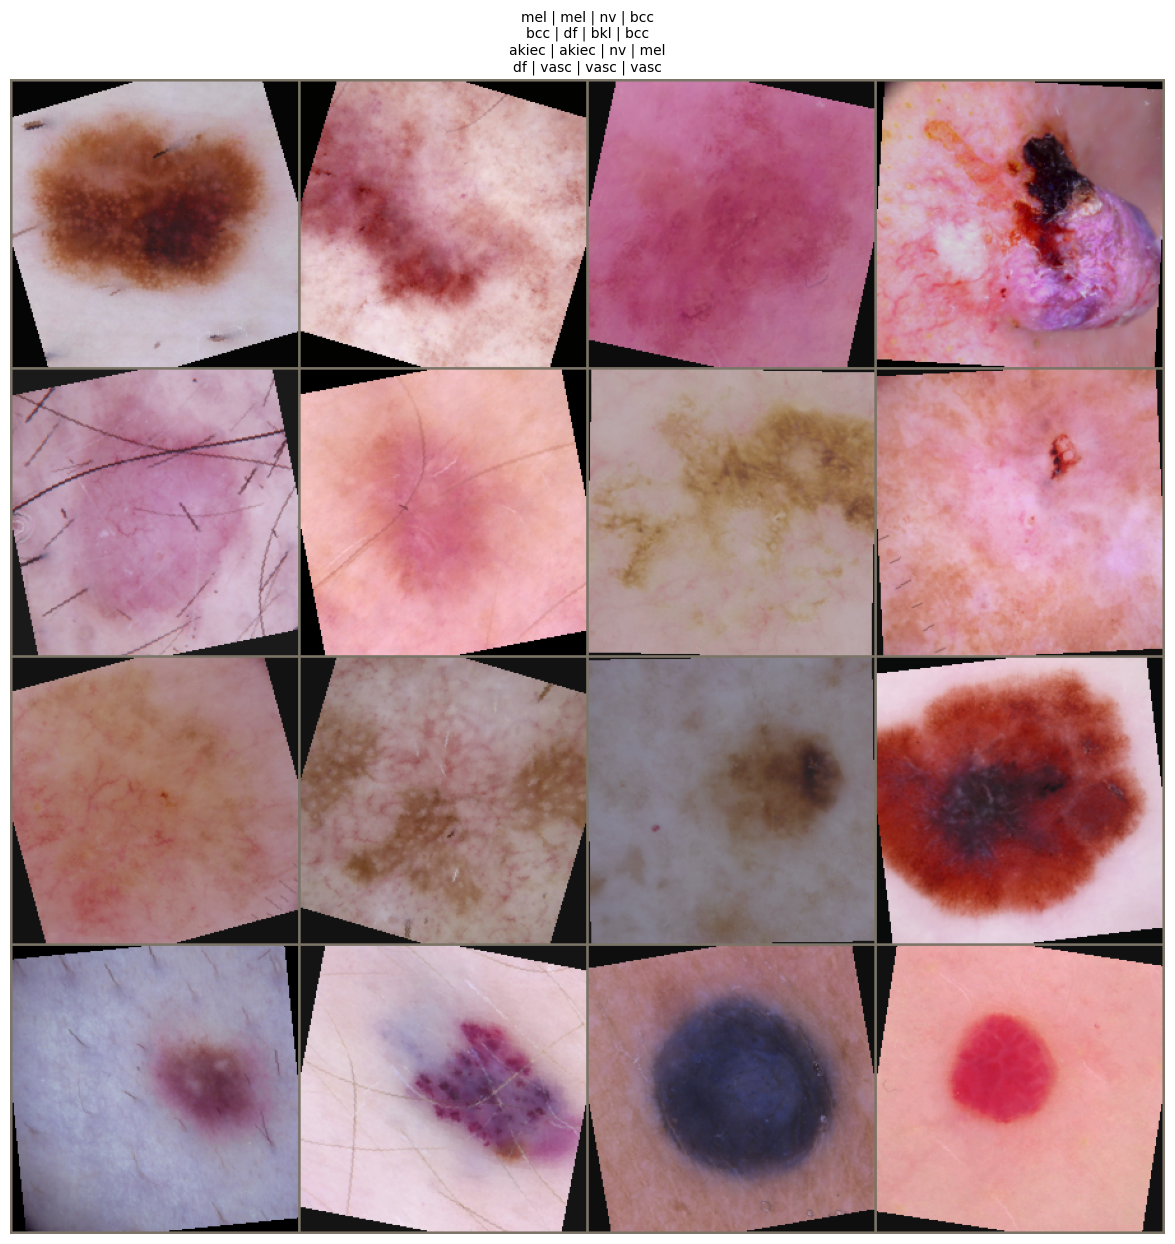


Répartition des classes dans ce batch aléatoire (sur 32 images) :
mel      6
bcc      6
df       6
vasc     5
akiec    4
nv       3
bkl      2
Name: count, dtype: int64
PyTorch a forcé l'apparition des classes rares pour équilibrer ce batch !


In [17]:
import torchvision
import matplotlib.pyplot as plt

# 1. Extraction d'un seul batch de 32 images et 32 labels
images, labels = next(iter(train_loader))

print(f"Format du Tenseur Image : {images.shape} -> [Batch, Canaux (RGB), Hauteur, Largeur]")
print(f"Format du Tenseur Label : {labels.shape}")

# 2. Inversion du dictionnaire pour retrouver le texte ('mel', 'nv', etc.)
idx_to_class = {v: k for k, v in label_map.items()}

# 3. Fonction de dénormalisation
def imshow(inp, title=None):
    """Dénormalise un Tenseur (C, H, W) et l'affiche via Matplotlib."""
    inp = inp.numpy().transpose((1, 2, 0)) # Passage de PyTorch (C,H,W) à Matplotlib (H,W,C)
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # Assure que les valeurs restent entre 0 et 1
    
    plt.figure(figsize=(15, 15))
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=10)
    plt.axis('off')
    plt.pause(0.001)

# 4. Création d'une grille avec torchvision (Affichons les 16 premières images du batch)
out = torchvision.utils.make_grid(images[:16], nrow=4)

# Récupération des noms complets pour le titre
batch_classes = [idx_to_class[labels[j].item()] for j in range(16)]
title_str = "\n".join([" | ".join(batch_classes[i:i+4]) for i in range(0, 16, 4)])

print("\n--- Visualisation d'un Batch d'Entraînement ---")
imshow(out, title=title_str)

# Comptage des classes dans CE batch spécifique
print("\nRépartition des classes dans ce batch aléatoire (sur 32 images) :")
batch_counts = pd.Series([idx_to_class[l.item()] for l in labels]).value_counts()
print(batch_counts)
print("PyTorch a forcé l'apparition des classes rares pour équilibrer ce batch !")

### Résumé

« *lors de cette deuxième phase, notre objectif n'était pas encore d'entraîner le modèle, mais de construire un pipeline d'alimentation de données robuste et sécurisé, de niveau "production". Nous avons structuré notre travail autour de trois piliers majeurs :*

**1. La Sécurité (Zéro Fuite de Données) :**
*Au lieu de faire une séparation Train/Test classique qui aurait mélangé les images au hasard, nous avons utilisé un algorithme de regroupement (`GroupShuffleSplit`) basé sur l'identifiant unique de chaque lésion (`lesion_id`). Cela garantit à 100 % qu'une IA ne verra jamais la photo d'un patient dans le Test s'il a déjà vu une autre photo de ce même patient dans le Train. Notre évaluation future sera donc totalement honnête.*

**2. La Préparation Hybride (Tabulaire + Image) :**
*Nous avons préparé le terrain pour nos deux futurs modèles :*
* *Pour le Random Forest (Tabulaire) : Nous avons nettoyé les données cliniques, imputé les âges manquants par la médiane, normalisé les valeurs et sauvegardé nos encodeurs (`.pkl`) pour pouvoir les réutiliser tels quels dans notre future application Web.*
* *Pour le CNN (Image) : Nous avons configuré les règles de redimensionnement et de normalisation mathématique exigées par l'architecture ImageNet.*

**3. La Gestion du Déséquilibre et la "Data Augmentation" :**
*Face au déséquilibre extrême de nos classes (beaucoup de Nævus, peu de Mélanomes), nous avons combiné deux techniques PyTorch exécutées "à la volée" dans la mémoire vive :*
* *Le **WeightedRandomSampler** : Un algorithme qui calcule des probabilités pour forcer la création de lots d'images (batches) parfaitement équilibrés.*
* *La **Data Augmentation** : Puisque le Sampler va piocher plusieurs fois les mêmes images rares (les mélanomes) pour compenser leur faible nombre, notre pipeline applique des rotations, des effets miroirs et des variations de couleurs aléatoires à chaque passage. Ainsi, le modèle n'apprend jamais l'image par cœur, mais apprend bien les caractéristiques de la pathologie.* »

***

### En une phrase très simple pour vous :
Dans la Phase 1, on a **analysé** les problèmes (déséquilibre, fuites). Dans cette Phase 2, on a construit **l'usine de traitement automatique** qui corrige ces problèmes juste avant d'envoyer les images au "cerveau" (le réseau de neurones).